In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import patches
import seaborn as sns
import os
import random
import re
import shutil
sns.set_style('darkgrid')
sns.set_palette('pastel')

import warnings
warnings.filterwarnings('ignore')

## 1. Dataset Class Definition

In [12]:
import os
import torch
from torch.utils.data import Dataset, DataLoader
import xml.etree.ElementTree as ET
from PIL import Image
import torchvision.transforms as T

class PCBDataset(Dataset):
    def __init__(self, root, transforms=None):
        self.root = root
        self.transforms = transforms
        self.classes = ['background', 'Spurious_copper', 'Open_circuit', 'Short', 'Mouse_bite', 'Spur', 'Missing_hole']
        # XML 내부의 소문자 태그와 매핑하기 위해 소문자 리스트도 준비
        self.classes_lower = [c.lower() for c in self.classes]
        self.class_to_idx = {cls.lower(): i for i, cls in enumerate(self.classes)}
        
        self.imgs = []
        self.anns = []
        
        img_dir = os.path.join(root, 'images')
        ann_dir = os.path.join(root, 'Annotations')
        
        # 실제 폴더 구조 순회
        for defect in os.listdir(img_dir):
            d_img_dir = os.path.join(img_dir, defect)
            d_ann_dir = os.path.join(ann_dir, defect)
            if os.path.isdir(d_img_dir) and os.path.isdir(d_ann_dir):
                for img_name in os.listdir(d_img_dir):
                    if img_name.endswith('.jpg'):
                        self.imgs.append(os.path.join(d_img_dir, img_name))
                        ann_name = img_name.replace('.jpg', '.xml')
                        self.anns.append(os.path.join(d_ann_dir, ann_name))

    def __getitem__(self, idx):
        img_path = self.imgs[idx]
        ann_path = self.anns[idx]
        
        img = Image.open(img_path).convert("RGB")
        
        boxes = []
        labels = []
        
        tree = ET.parse(ann_path)
        root = tree.getroot()
        for obj in root.findall('object'):
            label_text = obj.find('name').text.lower()
            if label_text not in self.class_to_idx:
                continue
            
            labels.append(self.class_to_idx[label_text])
            
            bndbox = obj.find('bndbox')
            xmin = float(bndbox.find('xmin').text)
            ymin = float(bndbox.find('ymin').text)
            xmax = float(bndbox.find('xmax').text)
            ymax = float(bndbox.find('ymax').text)
            
            # Faster R-CNN은 xmax > xmin, ymax > ymin을 요구함
            if xmax <= xmin: xmax = xmin + 1
            if ymax <= ymin: ymax = ymin + 1
            
            boxes.append([xmin, ymin, xmax, ymax])
            
        # [N, 4] 형태를 보장하기 위해 명시적으로 shape 지정
        if len(boxes) == 0:
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.as_tensor([], dtype=torch.int64)
        else:
            boxes = torch.as_tensor(boxes, dtype=torch.float32)
            labels = torch.as_tensor(labels, dtype=torch.int64)
        
        target = {}
        target["boxes"] = boxes
        target["labels"] = labels
        # 훈련 시 필요한 추가 필드
        target["image_id"] = torch.tensor([idx])
        target["area"] = (boxes[:, 3] - boxes[:, 1]) * (boxes[:, 2] - boxes[:, 0])
        target["iscrowd"] = torch.zeros((len(labels),), dtype=torch.int64)
        
        if self.transforms is not None:
            img = self.transforms(img)
            
        return img, target

    def __len__(self):
        return len(self.imgs)

def get_transform():
    return T.Compose([T.ToTensor()])


## 2. Model Initialization (Vanilla Faster R-CNN)

In [13]:
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

def get_model(num_classes):
    # Vanilla Faster R-CNN 로드
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights='DEFAULT')
    
    # 클래스 수에 맞게 head 변경
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    
    return model


## 3. Training Loop

In [ ]:
def collate_fn(batch):
    return tuple(zip(*batch))

# 데이터셋 설정
dataset_root = './data/PCB_DATASET'
dataset = PCBDataset(dataset_root, transforms=get_transform())

# Train/Test 분할
torch.manual_seed(42)
indices = torch.randperm(len(dataset)).tolist()
train_dataset = torch.utils.data.Subset(dataset, indices[:-100])
test_dataset = torch.utils.data.Subset(dataset, indices[-100:])

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False, collate_fn=collate_fn)

device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
model = get_model(num_classes=7)
model.to(device)

optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9, weight_decay=0.0005)
num_epochs = 10 

print("학습 시작...")
for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0
    for i, (images, targets) in enumerate(train_loader):
        images = list(image.to(device) for image in images)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
        
        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())
        
        optimizer.zero_grad()
        losses.backward()
        optimizer.step()
        
        epoch_loss += losses.item()
        
        if (i+1) % 10 == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{len(train_loader)}], Loss: {losses.item():.4f}")
            
    print(f"Epoch {epoch+1} Average Loss: {epoch_loss/len(train_loader):.4f}")
print("학습 완료.")


학습 시작...
Epoch [1/10], Step [10/149], Loss: 0.4414
Epoch [1/10], Step [20/149], Loss: 0.5536
Epoch [1/10], Step [30/149], Loss: 0.3009
Epoch [1/10], Step [40/149], Loss: 0.4058
Epoch [1/10], Step [50/149], Loss: 0.4981
Epoch [1/10], Step [60/149], Loss: 0.5038
Epoch [1/10], Step [70/149], Loss: 0.3470
Epoch [1/10], Step [80/149], Loss: 0.5346
Epoch [1/10], Step [90/149], Loss: 0.3523
Epoch [1/10], Step [100/149], Loss: 0.6435
Epoch [1/10], Step [110/149], Loss: 0.3135
Epoch [1/10], Step [120/149], Loss: 0.4561
Epoch [1/10], Step [130/149], Loss: 0.5026
Epoch [1/10], Step [140/149], Loss: 0.3928
Epoch 1 Average Loss: 0.5718
Epoch [2/10], Step [10/149], Loss: 0.5001
Epoch [2/10], Step [20/149], Loss: 0.5315
Epoch [2/10], Step [30/149], Loss: 0.6803
Epoch [2/10], Step [40/149], Loss: 0.4620
Epoch [2/10], Step [50/149], Loss: 0.6618
Epoch [2/10], Step [60/149], Loss: 0.5004
Epoch [2/10], Step [70/149], Loss: 0.4467
Epoch [2/10], Step [80/149], Loss: 0.4766
Epoch [2/10], Step [90/149], Loss

## 4. Evaluation

mAP 계산 중...
mAP (IoU=0.50:0.95): 0.4406
mAP (IoU=0.50): 0.9388
mAP (IoU=0.75): 0.3526


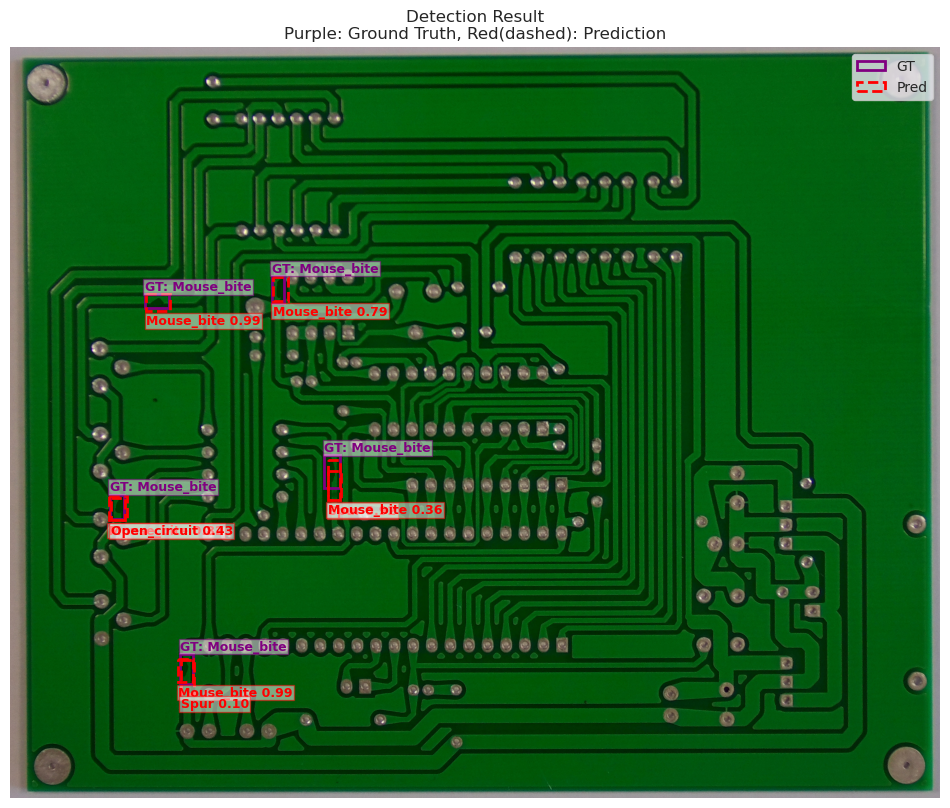

In [ ]:
from torchmetrics.detection.mean_ap import MeanAveragePrecision
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torch


print("mAP 계산 중...")
metric = MeanAveragePrecision(box_format='xyxy', class_metrics=True)
model.eval()

with torch.no_grad():
    for images, targets in test_loader:
        images = list(img.to(device) for img in images)
        preds = model(images)
        
        preds_cpu = [{k: v.cpu() for k, v in t.items()} for t in preds]
        targets_cpu = [{k: v.cpu() for k, v in t.items()} for t in targets]
        metric.update(preds_cpu, targets_cpu)

mAP_results = metric.compute()
print(f"mAP (IoU=0.50:0.95): {mAP_results['map'].item():.4f}")
print(f"mAP (IoU=0.50): {mAP_results['map_50'].item():.4f}")
print(f"mAP (IoU=0.75): {mAP_results['map_75'].item():.4f}")

with torch.no_grad():
    image, target = test_dataset[0]
    prediction = model([image.to(device)])[0]

image_np = image.permute(1, 2, 0).numpy()
fig, ax = plt.subplots(1, figsize=(12, 12))
ax.imshow(image_np)

# Ground Truth 박스 그리기 (보라색)
for box, label_idx in zip(target['boxes'].numpy(), target['labels'].numpy()):
    xmin, ymin, xmax, ymax = box
    rect = patches.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin, 
                             linewidth=2, edgecolor='purple', facecolor='none', label='GT')
    ax.add_patch(rect)
    
    label_name = dataset.classes[label_idx]
    ax.text(xmin, ymin - 12, f"GT: {label_name}", color='purple', fontsize=9, fontweight='bold',
            bbox=dict(facecolor='white', alpha=0.5, edgecolor='purple', pad=1)) # 배경을 반투명 흰색으로, 테두리만 보라색

# 예측된 바운딩 박스 그리기 (빨간색)
scores = prediction['scores'].cpu().numpy()
boxes = prediction['boxes'].cpu().numpy()
labels = prediction['labels'].cpu().numpy()

for box, score, label_idx in zip(boxes, scores, labels):
    if score > 0.1: 
        xmin, ymin, xmax, ymax = box
        rect = patches.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin, 
                                 linewidth=2, edgecolor='r', facecolor='none', linestyle='--', label='Pred')
        ax.add_patch(rect)
        
        label_name = dataset.classes[label_idx]
        ax.text(xmin, ymax + 12, f"{label_name} {score:.2f}", color='red', fontsize=9, fontweight='bold',
                bbox=dict(facecolor='white', alpha=0.5, edgecolor='red', pad=1),
                verticalalignment='top')

handles, labels_legend = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels_legend, handles))
plt.legend(by_label.values(), by_label.keys(), loc='upper right')

plt.title(f"Detection Result\nPurple: Ground Truth, Red(dashed): Prediction")
plt.axis('off')
plt.show()